# MLB Salary Cap Analysis - Case Study 3

## Research Question
With MLB owners proposing a \\$245.3M cap and \\$171.2M floor for the 2027 season, 
which teams face the greatest structural pressure on either end — and what does 
20 years of World Series history suggest about what's actually at stake competitively?

## Structure
1. Cap Pressure - teams currently above \$245.3M
2. Floor Pressure - teams currently under \$171.2M
3. World Series History - payroll of champions over last 20 years
4. Closing Thesis - asymmetric pressure analysis

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd        # tabular data — loading, filtering, merging, transforming
import numpy as np         # numerical operations and array math
import matplotlib.pyplot as plt  # base visualization library
import seaborn as sns      # statistical visualizations, cleaner defaults than raw matplotlib
import pybaseball as pb    # pulls data from Baseball Reference, FanGraphs, Statcast
import requests

#### Section 1 — Cap Pressure

Identifying which MLB teams currently exceed the proposed \$245.3M salary cap, 
and quantifying how much they would need to shed to comply.

### Data Source — 2026 Team Payrolls

Current team payroll data is sourced from Spotrac, which tracks real-time 
MLB salary commitments. Since no direct download is available, we scrape 
the data programmatically using pandas' `read_html()` function. We're using 
2026 figures as the most relevant proxy for evaluating pressure against the 
proposed 2027 salary cap and floor thresholds.

In [3]:
# url = 'https://www.spotrac.com/mlb/payroll/_/year/2026'
# tables = pd.read_html(url)
# print(len(tables))

# headers = {'User-Agent': 'Mozilla/5.0'}
# response = requests.get(url, headers=headers)
# tables = pd.read_html(response.text)
# print(len(tables))

### A Note on Data Collection

Initial efforts to scrape 2026 team payroll figures directly from Spotrac 
were unsuccessful due to the site's use of JavaScript to render its data 
tables. Attempts using `requests` and `pd.read_html()` retrieved only 
static HTML — the payroll table itself is loaded dynamically and requires 
a browser to execute. A full scraping solution would utilize Python's 
`Selenium` package to control a headless browser and capture the rendered 
output. For simplicity, 2026 payroll figures were manually collected from 
Spotrac and loaded via CSV.

In [4]:
payroll_df = pd.read_csv('spotrac-team-payroll-2026.csv')
payroll_df.head()

,Team,Total Payroll
0,PHI,"280,839,235"
1,TOR,"282,552,776"
2,NYY,"292,892,832"
3,NYM,"334,085,472"
4,ATL,"267,889,815"


In [5]:
payroll_df.dtypes

Team             str
Total Payroll    str
dtype: object

In [6]:
payroll_df['Total Payroll'] = payroll_df['Total Payroll'].str.replace(',','').astype(int)

In [7]:
payroll_df.head()

,Team,Total Payroll
0,PHI,280839235
1,TOR,282552776
2,NYY,292892832
3,NYM,334085472
4,ATL,267889815


In [8]:
CAP = 245_300_000 # underscores are just visual
over_cap = payroll_df[payroll_df['Total Payroll'] > CAP].copy()
print(over_cap)

  Team  Total Payroll
0  PHI      280839235
1  TOR      282552776
2  NYY      292892832
3  NYM      334085472
4  ATL      267889815
5  LAD      302198379


In [9]:
over_cap['Over Cap'] = over_cap['Total Payroll'] - CAP
over_cap.sort_values('Over Cap', ascending=False)

,Team,Total Payroll,Over Cap
3,NYM,334085472,88785472
5,LAD,302198379,56898379
2,NYY,292892832,47592832
1,TOR,282552776,37252776
0,PHI,280839235,35539235
4,ATL,267889815,22589815


This is looking at the teams who would fall over the cap limit. Taking the difference ("Over Cap"), leaves us with three teams over /$45 million that they would need to shed. That's likely a taller task than the bottom three (TOR, PHI, ATL) which would likely need to remove bloated middle-relief contracts from their payroll.  

In [10]:
FLOOR = 171_200_000
under_floor = payroll_df[payroll_df['Total Payroll'] < FLOOR].copy()
under_floor.count()

Team             15
Total Payroll    15
dtype: int64

In [11]:
under_floor['Under Floor'] = FLOOR - under_floor['Total Payroll']
under_floor.sort_values('Under Floor', ascending=False)

,Team,Total Payroll,Under Floor
26,MIA,80374373,90825627
23,CLE,80471618,90728382
27,CHW,90997868,80202132
29,WSH,92605844,78594156
28,STL,93898025,77301975
24,ATH,94163715,77036285
21,TB,103281480,67918520
17,PIT,103967933,67232067
25,MIN,105992179,65207821
22,COL,118106572,53093428


A note on the data: we're using 2026 salary totals to evaluate teams against the proposed 2027 cap and floor. These aren't 2027 commitments — payrolls shift year to year as contracts expire and teams restructure — so this is a best-available proxy rather than a precise forecast. It's directionally sound for identifying which teams face structural pressure, but actual 2027 figures will move. 

In [12]:
print(over_cap['Over Cap'].sum())
print(under_floor['Under Floor'].sum())

288658509
862583363


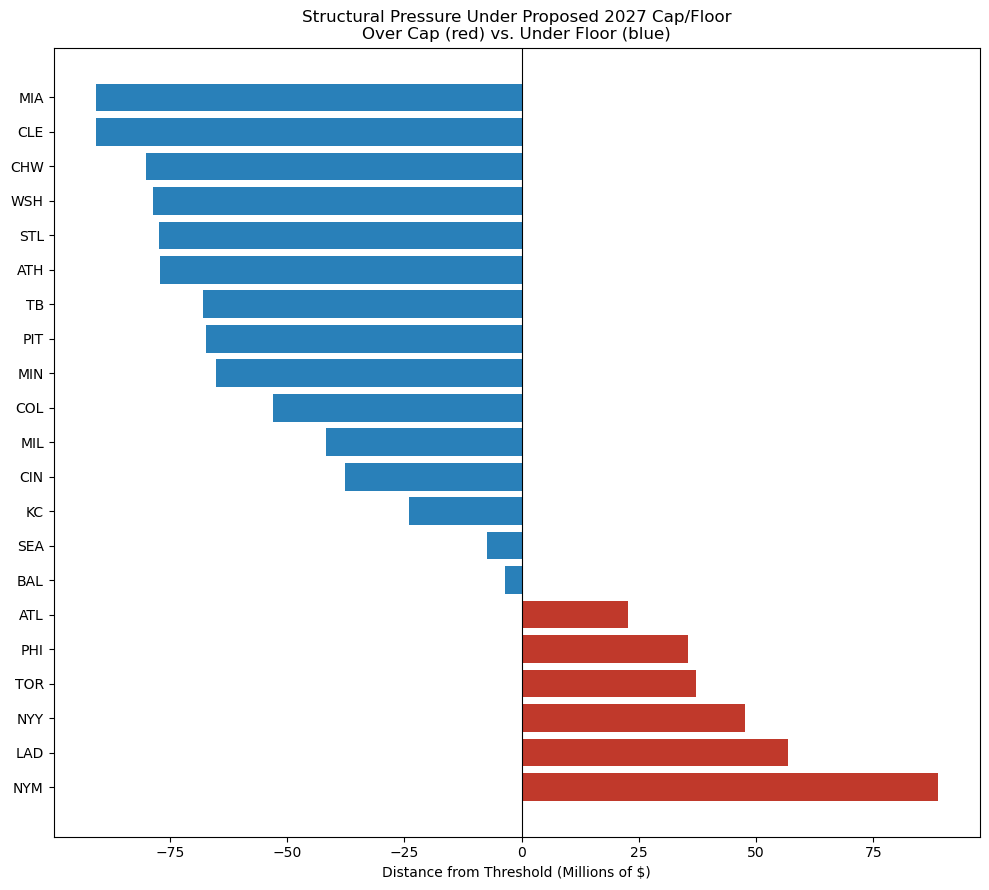

In [13]:
# Cap teams = positive distance from the line
cap_plot = over_cap[['Team', 'Over Cap']].copy()
cap_plot = cap_plot.rename(columns={'Over Cap': 'Distance'})
cap_plot['Side'] = 'Over Cap'

floor_plot = under_floor[['Team', 'Under Floor']].copy()
floor_plot = floor_plot.rename(columns={'Under Floor': 'Distance'})
floor_plot['Distance'] = -floor_plot['Distance']
floor_plot['Side'] = 'Under Floor'

#combine both sides into one dataframe
combined = pd.concat([cap_plot, floor_plot])
combined = combined.sort_values('Distance', ascending=False)

#Plot
fig, ax = plt.subplots(figsize=(10, 9))
colors = combined['Side'].map({'Over Cap': '#c0392b', 'Under Floor': '#2980b9'})
ax.barh(combined['Team'], combined['Distance']/1_000_000, color=colors)

ax.axvline(0, color='black', linewidth=0.8) #threshould line at 0
ax.set_xlabel('Distance from Threshold (Millions of $)')
ax.set_title('Structural Pressure Under Proposed 2027 Cap/Floor\nOver Cap (red) vs. Under Floor (blue)')
plt.tight_layout()
plt.show()

In [14]:
# Import the World Series contenders from 2025-2025
# Pulled data from https://www.thebaseballcube.com/content/payroll/#google_vignette
world_series_df = pd.read_csv('2005-2025-ws-payroll.csv')
world_series_df.head()

,year,champion,contender,champion-payroll,contender-payroll,league-total-payroll
0,2005,CHW,HOU,"75,228,000","76,779,022","2,191,886,898"
1,2006,STL,DET,"88,891,371","82,612,866","2,326,706,685"
2,2007,BOS,COL,"143,026,214","54,424,000","2,476,688,987"
3,2008,PHI,TB,"98,269,880","43,820,597","2,686,433,458"
4,2009,NYY,PHI,"201,449,289","113,004,048","2,655,395,194"


In [15]:
world_series_df['champion-payroll'] = world_series_df['champion-payroll'].str.replace(',','').astype(int)
world_series_df['contender-payroll'] = world_series_df['contender-payroll'].str.replace(',','').astype(int)
world_series_df.dtypes

year                    int64
champion                  str
contender                 str
champion-payroll        int64
contender-payroll       int64
league-total-payroll      str
dtype: object

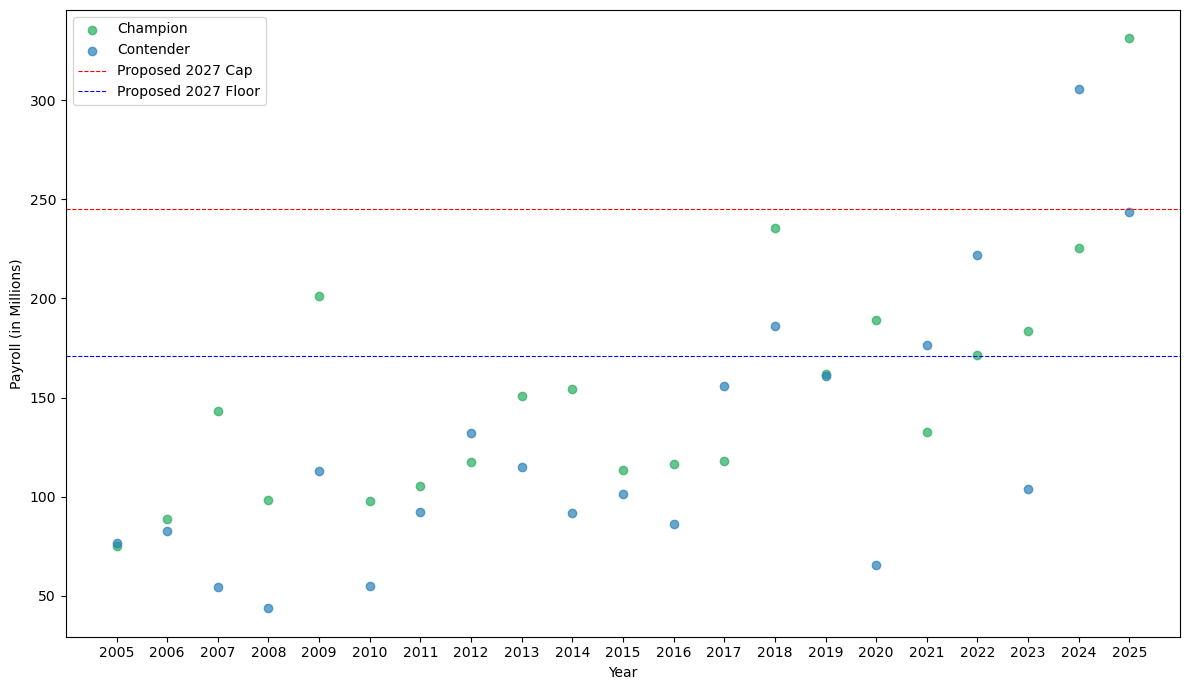

In [16]:
champions = world_series_df[['year','champion','champion-payroll']].copy()
champions = champions.rename(columns={'champion':'team','champion-payroll':'payroll'})
champions['Result'] = 'Champion'

contenders = world_series_df[['year','contender','contender-payroll']].copy()
contenders = contenders.rename(columns={'contender':'team','contender-payroll':'payroll'})
contenders['Result'] = 'Contender'

world_series_plot = pd.concat([champions,contenders])
fig, ax = plt.subplots(figsize=(12, 7))
champ = world_series_plot[world_series_plot['Result'] == 'Champion']
cont  = world_series_plot[world_series_plot['Result'] == 'Contender']

ax.scatter(champ['year'], champ['payroll']/1_000_000, color='#27ae60', alpha=0.7, label='Champion')
ax.scatter(cont['year'],  cont['payroll']/1_000_000,  color='#2980b9', alpha=0.7, label='Contender')


ax.axhline(245.3, color='red', linewidth=0.8, linestyle='--', label='Proposed 2027 Cap')
ax.axhline(171.2, color='blue', linewidth=0.8, linestyle='--', label='Proposed 2027 Floor')
ax.set_xticks(world_series_plot['year'].unique())
ax.legend()
ax.set_xlabel('Year')
ax.set_ylabel('Payroll (in Millions)')
plt.tight_layout()
plt.show()


This chart plots opening-day payroll for both World Series participants — the champion (green) and the contender they defeated (blue) — for every season from 2005 to 2025, against the proposed 2027 cap ($245.3M) and floor ($171.2M).

Two patterns stand out. First, almost no team — champion or contender — would have exceeded the proposed cap; only the most recent seasons approach it. Second, a large share of teams fall *below* the proposed floor, including multiple World Series champions (e.g., the 2005 White Sox at ~$75M). A spending floor meant to enforce competitiveness would have flagged several of the sport's most successful teams as underspenders.

This mirrors the asymmetry from Section 1: the cap constrains few teams, while the floor pressures many. One important caveat: because MLB payrolls have grown steadily since 2005, earlier teams sit low partly due to nominal-dollar drift rather than genuinely low relative spending. The next section isolates the real effect by ranking each team's payroll *within its own season*, removing inflation from the comparison.